<a href="https://colab.research.google.com/github/ridwanrahman326-netizen/MIT_APP/blob/main/Modified_SMS_Spam_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SMS Spam Classification using SVM
Dataset: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset?resource=download

In [35]:
# Install (if needed)
!pip -q install wordcloud nltk scikit-learn


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import nltk
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Upload dataset (`spam.csv`) downloaded from Kaggle.

In [37]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam (2).csv


In [38]:
df = pd.read_csv("spam.csv", encoding="latin-1")

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [39]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df['label'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Missing values:
label      0
message    0
dtype: int64

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


## Exploratory Data Analysis

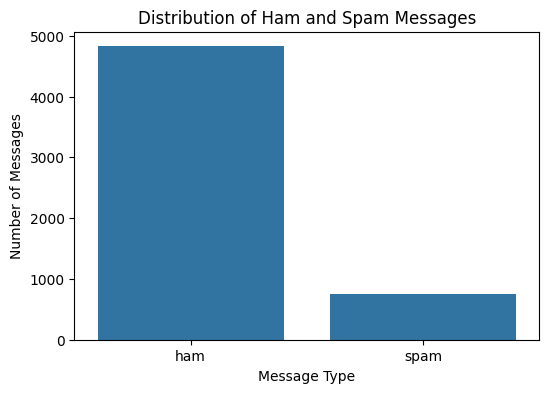

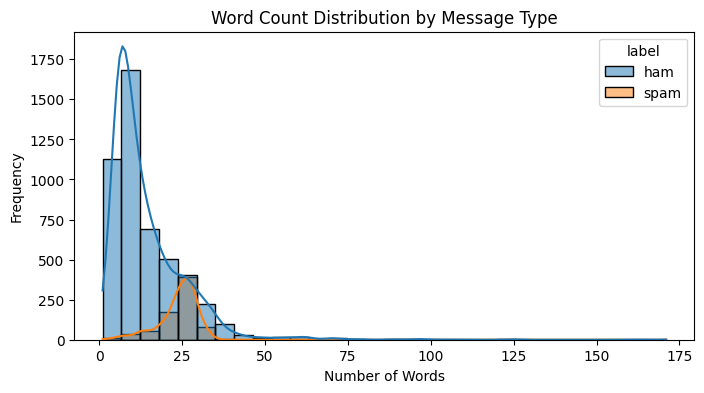

In [40]:
df['char_count'] = df['message'].str.len()
df['word_count'] = df['message'].str.split().str.len()
df['digit_count'] = df['message'].str.count(r'\d')
df['exclamation_count'] = df['message'].str.count('!')
df['question_count'] = df['message'].str.count(r'\?')

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title('Distribution of Ham and Spam Messages')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(
    data=df,
    x='word_count',
    hue='label',
    bins=30,
    kde=True
)
plt.title('Word Count Distribution by Message Type')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()



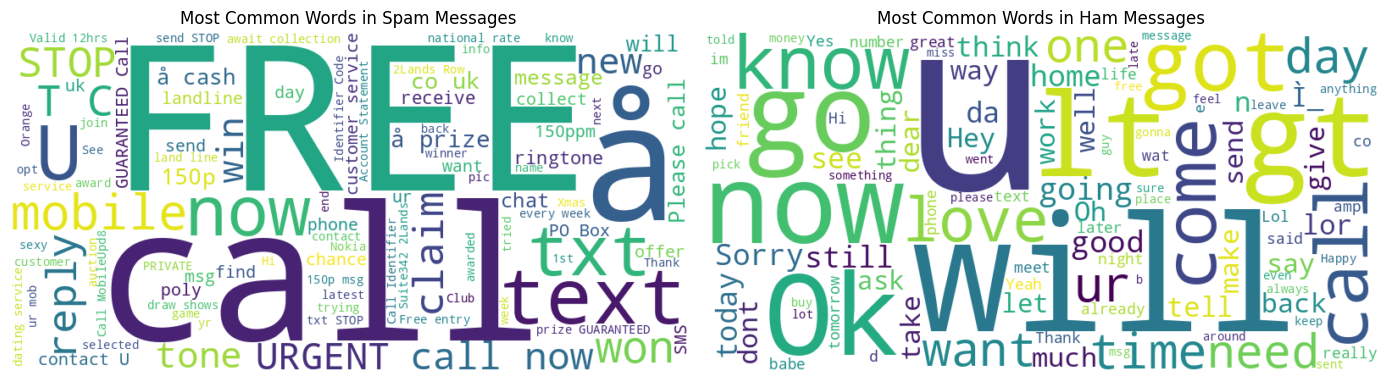

In [41]:
spam = ' '.join(df[df['label'] == 'spam']['message'])
ham = ' '.join(df[df['label'] == 'ham']['message'])

spam_wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate(spam)

ham_wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate(ham)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(spam_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Spam Messages')

plt.subplot(1, 2, 2)
plt.imshow(ham_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Ham Messages')

plt.tight_layout()
plt.show()


## Preprocessing

In [43]:
import re
from nltk.stem import WordNetLemmatizer

lemm = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    # Replace URLs
    text = re.sub(r'http\S+|www\S+', ' URL ', text)

    # Replace email addresses
    text = re.sub(r'\S+@\S+', ' EMAIL ', text)

    # Replace numbers
    text = re.sub(r'\d+', ' NUM ', text)

    # Keep useful spam-related symbols
    text = re.sub(r'[^a-zA-Z0-9!$%? ]', ' ', text)

    # Lemmatize without removing stopwords
    tokens = [
        lemm.lemmatize(word)
        for word in text.split()
    ]

    return ' '.join(tokens)


# Remove duplicate messages
df = df.drop_duplicates()

# Clean messages
df['clean_message'] = df['message'].apply(clean_text)

# Convert labels from text to numbers
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

# Check for missing labels
df = df.dropna(subset=['label'])

# Convert labels to integers
df['label'] = df['label'].astype(int)

print("Dataset shape:", df.shape)
print("\nLabel distribution:")
print(df['label'].value_counts())

df.head()

Dataset shape: (5169, 8)

Label distribution:
label
0    4516
1     653
Name: count, dtype: int64


,label,message,char_count,word_count,digit_count,exclamation_count,question_count,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",111,20,0,0,0,go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,29,6,0,0,0,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,25,0,0,free entry in NUM a wkly comp to win fa cup fi...
3,0,U dun say so early hor... U c already then say...,49,11,0,0,0,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,0,0,0,nah i don t think he go to usf he life around ...


## Train/Test Split

In [44]:
from sklearn.model_selection import train_test_split

# Input features and target
X = df['clean_message']
y = df['label']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTesting label distribution:")
print(y_test.value_counts())


Training samples: 4135
Testing samples: 1034

Training label distribution:
label
0    3613
1     522
Name: count, dtype: int64

Testing label distribution:
label
0    903
1    131
Name: count, dtype: int64


## SVM Model

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=15000,
        ngram_range=(1, 3),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        strip_accents='unicode'
    )),

    ('svm', LinearSVC(
        C=1.5,
        class_weight='balanced'
    ))
])

pipeline.fit(X_train, y_train)

pred = pipeline.predict(X_test)

print("===== SVM Model Performance =====")
print(f"Accuracy : {accuracy_score(y_test, pred):.4f}")
print(f"Precision: {precision_score(y_test, pred):.4f}")
print(f"Recall   : {recall_score(y_test, pred):.4f}")
print(f"F1 Score : {f1_score(y_test, pred):.4f}")

print("\n===== Classification Report =====")
print(classification_report(
    y_test,
    pred,
    target_names=['Ham', 'Spam']
))



===== SVM Model Performance =====
Accuracy : 0.9865
Precision: 0.9606
Recall   : 0.9313
F1 Score : 0.9457

===== Classification Report =====
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       903
        Spam       0.96      0.93      0.95       131

    accuracy                           0.99      1034
   macro avg       0.98      0.96      0.97      1034
weighted avg       0.99      0.99      0.99      1034



## Hyperparameter Tuning

In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'tfidf__max_features': [10000, 15000],
    'tfidf__ngram_range': [(1, 2), (1, 3)],
    'svm__C': [0.5, 1.0, 1.5, 2.0]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(f"{grid.best_score_:.4f}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters:
{'svm__C': 1.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}

Best Cross-Validation F1 Score:
0.9536


## Cross Validation

In [47]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    grid.best_estimator_,
    df['clean_message'],
    df['label'],
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("F1 Scores for each fold:")
print(scores)

print("\nMean F1 Score:", scores.mean())
print("Standard Deviation:", scores.std())


F1 Scores for each fold:
[0.93927126 0.96969697 0.95719844 0.95785441 0.96946565]

Mean F1 Score: 0.9586973446645392
Standard Deviation: 0.011111060553532318


## Prediction Function

In [48]:
# Use the best model found by GridSearchCV
model = grid.best_estimator_

def predict_sms(text):
    cleaned_text = clean_text(text)
    prediction = model.predict([cleaned_text])[0]

    return "SPAM" if prediction == 1 else "HAM"


# Test messages
test_messages = [
    "Congratulations! You have won a free iPhone. Click here now.",
    "Hi, are we meeting tomorrow at 3 PM?",
    "URGENT! You have won $1000. Call now!",
    "Can you send me the assignment notes?",
    "Free entry to win a cash prize! Reply NOW!",
    "Your appointment is confirmed for tomorrow."
]

# Display predictions
for message in test_messages:
    print("Message:", message)
    print("Prediction:", predict_sms(message))
    print("-" * 60)


Message: Congratulations! You have won a free iPhone. Click here now.
Prediction: SPAM
------------------------------------------------------------
Message: Hi, are we meeting tomorrow at 3 PM?
Prediction: HAM
------------------------------------------------------------
Message: URGENT! You have won $1000. Call now!
Prediction: SPAM
------------------------------------------------------------
Message: Can you send me the assignment notes?
Prediction: HAM
------------------------------------------------------------
Message: Free entry to win a cash prize! Reply NOW!
Prediction: SPAM
------------------------------------------------------------
Message: Your appointment is confirmed for tomorrow.
Prediction: HAM
------------------------------------------------------------
